# Veri Bölme Stratejileri (Cross-Validation)

## Genel Amaç

Bu defter, makine öğrenmesi modellerini değerlendirmek için kullanılan temel veri bölme (split) stratejilerini kapsamlı şekilde açıklamaktadır. 

**Neden önemlidir?** Doğru bir bölme stratejisi seçmek, modelin gerçek dünya performansını güvenilir şekilde tahmin etmemizi sağlar. Hatalı bölme yöntemi seçilirse, model performansının abartılı (overfitting) veya düşük (underfitting) tahmin edilmesi riski vardır.

Bu defter aşağıdaki stratejileri detaylı olarak incelemektedir:
- **Train-Test Split**: Basit tek bölme yöntemi
- **K-Fold Cross-Validation**: Döngüsel bölme stratejisi
- **Stratified K-Fold**: Sınıf dengesi koruyan bölme
- **Group K-Fold**: Grup yapısını koruyan bölme
- **Time Series Split**: Zaman serisi için bölme

Aşağıdaki bölümlerde her yöntemin matematiksel temeli, parametreleri ve kullanım senaryoları ele alınmaktadır.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from dataclasses import dataclass
from sklearn.model_selection import (
                                      train_test_split,
                                      KFold,
                                      StratifiedKFold,
                                      GroupKFold,
                                      TimeSeriesSplit,
                                      RepeatedKFold
                                    )
%matplotlib inline
sns.set_theme(style='whitegrid')

In [25]:
def create_dataset(n_samples=120):
    np.random.seed(42)
    df = pd.DataFrame({
        'date': pd.date_range(start='2023-01-01', periods=n_samples, freq='D'),
        'feature': np.random.rand(n_samples).cumsum(),
        'target': np.random.choice( [0, 1], size=n_samples, p=[0.2, 0.8]),
        'group_id': np.repeat(np.arange(10), n_samples // 10)
    })
    return df
df = create_dataset()
df.head()

,date,feature,target,group_id
0,2023-01-01,0.374540,1,0
1,2023-01-02,1.325254,1,0
2,2023-01-03,2.057248,1,0
3,2023-01-04,2.655907,0,0
4,2023-01-05,2.811925,1,0


## Train-Test Split

**Amaç:** Veri setini eğitim ve test kümelerine basit şekilde bölmek.

**Matematiksel İlke:** Veriler rastgele (shuffle=True) kullanılarak, belirli bir oran (test_size) kadar test seti ayrılır. Varsayılan oran %20 test ve %80 eğitim.

**Parametreler:**
- `test_size=0.2`: Toplam verinin %20'si test için ayrılır
- `random_state=42`: Tekrarlanabilir sonuçlar için sabit seed değeri
- `shuffle=True`: Veri indekslerinin rastgele karıştırılması

**Ne zaman kullanılır?** Sınıflandırma modellerinin basit, tek seferlik değerlendirilmesinde.

In [26]:
train_idx, test_idx = train_test_split(df.index, test_size=0.2, random_state=42, shuffle=True )

print(f'Train : {len(train_idx)}, Test : {len(test_idx)}')

Train : 96, Test : 24


## K-Fold Cross Validation

**Amaç:** Veri setini k sayıda eşit parçaya bölerek, her parçayı sırasıyla test seti olarak kullanmak.

**Matematiksel İlke:** N örnek, k=5 eşit parçaya bölünür. Her iterasyonda, k-1 parça eğitim, 1 parça validasyon olur. Sonuçlar ortalaması alınır.

$$CV_{score} = \frac{1}{k}\sum_{i=1}^{k} score_i$$

**Parametreler:**
- `n_splits=5`: Kaç parçaya bölüneceğini belirler
- `shuffle=True`: Her fold'ün rastgele seçilmesini sağlar
- `random_state=42`: Tekrarlanabilirlik için seed değeri

**Ne zaman kullanılır?** Küçük veri setlerinde daha güvenilir model performans değerlendirmesi.

In [27]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (t_idx, v_idx) in enumerate(kf.split(df)):
    print(f'Fold {fold + 1}: Train: {len(t_idx)}, Validation: {len(v_idx)}')

Fold 1: Train: 96, Validation: 24
Fold 2: Train: 96, Validation: 24
Fold 3: Train: 96, Validation: 24
Fold 4: Train: 96, Validation: 24
Fold 5: Train: 96, Validation: 24


## Stratified K-Fold

**Amaç:** Sınıf dengesizliğini koruyarak K-Fold uygulamak.

**Matematiksel İlke:** Her fold'ün hedef değişkenin oransal dağılımını orijinal veri setinde olduğu gibi koruması sağlanır. Eğer veri seti %80 pozitif sınıfsa, her fold'de de %80 pozitif sınıf bulunur.

$$\text{Oranı} = \frac{\text{Pozitif Sınıfların Sayısı}}{\text{Toplam Örnek Sayısı}}$$

**Parametreler:**
- `n_splits=5`: Fold sayısı
- `shuffle=False`: Varsayılan olarak rastgele karıştırmaz (opsiyonel)

**Ne zaman kullanılır?** Sınıf dengesiz veri setlerinde (örneğin sahtekarlık tespiti, nadir hastalık tahmini).

In [28]:
skf = StratifiedKFold(n_splits=5)

for fold, (t_idx, v_idx) in enumerate(skf.split(df, df['target'])):
 
    ratio = df.iloc[v_idx]['target'].mean()
    print(f"Fold {fold+1} Target=1 Oranı: {ratio:.2f}")

Fold 1 Target=1 Oranı: 0.83
Fold 2 Target=1 Oranı: 0.79
Fold 3 Target=1 Oranı: 0.79
Fold 4 Target=1 Oranı: 0.79
Fold 5 Target=1 Oranı: 0.79


## Group K-Fold

**Amaç:** Veri noktalarının grup bilgisini dikkate alarak bölmek (aynı grup eğitim ve test'e dağılmaz).

**Matematiksel İlke:** Her fold'de, belirli grup ID'leri tam olarak test seti olur, diğer grup ID'leri eğitim seti olur. 

$$\text{Test Seti} = \{x_i : \text{group}(x_i) \in \text{TestGrupları}\}$$

**Parametreler:**
- `n_splits=5`: Kaç fold oluşturulacağı
- `groups`: Her örneğin ait olduğu grup ID'si (dataframe sütunu)

**Ne zaman kullanılır?** Aynı hastanın birden fazla örneği, aynı yazar'ın birden fazla yazısı gibi bağımlı veriler varsa. Grup sızıntısını (data leakage) önler.

In [29]:
gkf = GroupKFold(n_splits=5)

for fold, (t_idx, v_idx) in enumerate(gkf.split(df, groups=df['group_id'])):
    unique_groups = df.iloc[v_idx]['group_id'].unique()
    print(f"Fold {fold+1} İçindeki Gruplar: {unique_groups}")

Fold 1 İçindeki Gruplar: [4 9]
Fold 2 İçindeki Gruplar: [3 8]
Fold 3 İçindeki Gruplar: [2 7]
Fold 4 İçindeki Gruplar: [1 6]
Fold 5 İçindeki Gruplar: [0 5]


## TimeSeriesSplit

**Amaç:** Zaman serisi verilerinde "gelecekten geçmişe sızıntı" (forward leakage) olmadan bölmek.

**Matematiksel İlke:** Zaman boyunca ilerleyerek her fold'de, eğitim seti tüm geçmiş veriler, test seti gelecek veriler olur.

$$\text{Fold}_i: \text{Train} = [t_1, t_2, ..., t_j] \quad \text{Test} = [t_{j+1}, ..., t_n]$$

**Parametreler:**
- `n_splits=5`: Kaç fold oluşturulacağı
- `max_train_size`: Eğitim setinin maksimum boyutu (opsiyonel)
- `test_size`: Test setinin sabit boyutu (opsiyonel)

**Ne zaman kullanılır?** Zaman serisi verilerinde (hisse senedi fiyatları, hava durumu tahminleri, sensör verileri vb.) gerçekçi model değerlendirmesi için.

In [30]:
tscv = TimeSeriesSplit(n_splits=5)

for fold, (t_idx, v_idx) in enumerate(tscv.split(df)):
    print(f"Fold {fold+1}: Eğitim Aralığı {t_idx[0]}-{t_idx[-1]} | Test Aralığı {v_idx[0]}-{v_idx[-1]}")

Fold 1: Eğitim Aralığı 0-19 | Test Aralığı 20-39
Fold 2: Eğitim Aralığı 0-39 | Test Aralığı 40-59
Fold 3: Eğitim Aralığı 0-59 | Test Aralığı 60-79
Fold 4: Eğitim Aralığı 0-79 | Test Aralığı 80-99
Fold 5: Eğitim Aralığı 0-99 | Test Aralığı 100-119


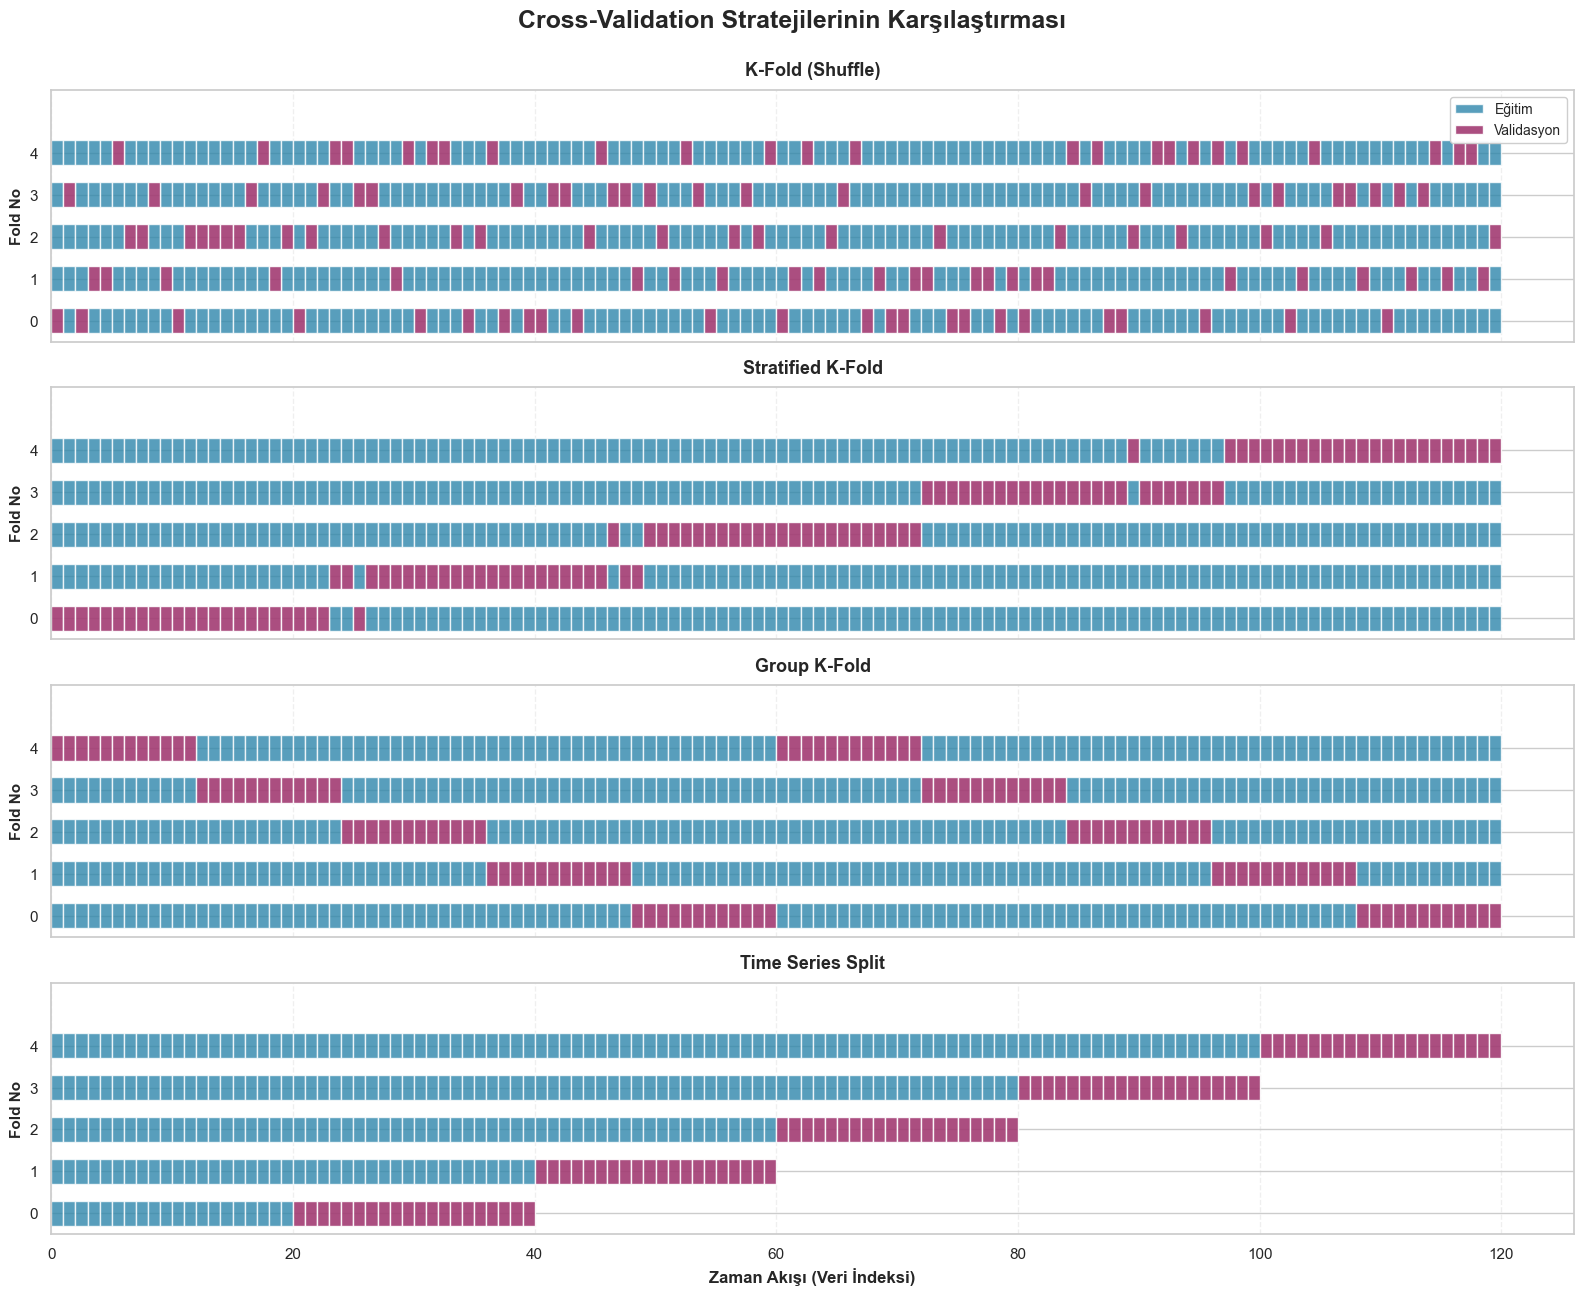

In [31]:
def plot_all_splits(df):
    splitters = [
        ("K-Fold (Shuffle)", KFold(n_splits=5, shuffle=True)),
        ("Stratified K-Fold", StratifiedKFold(n_splits=5)),
        ("Group K-Fold", GroupKFold(n_splits=5)),
        ("Time Series Split", TimeSeriesSplit(n_splits=5))
    ]
    
    fig, axes = plt.subplots(len(splitters), 1, figsize=(16, 13), sharex=True)
    fig.suptitle('Cross-Validation Stratejilerinin Karşılaştırması', fontsize=18, fontweight='bold', y=0.995)
    
    for i, (name, splitter) in enumerate(splitters):
        ax = axes[i]
        indices = list(splitter.split(df, df['target'], groups=df['group_id']))
        
        for fold, (train_idx, val_idx) in enumerate(indices):
            ax.barh([fold]*len(train_idx), [1]*len(train_idx), left=train_idx, height=0.6, 
                   color='#2E86AB', alpha=0.8, label='Eğitim' if fold == 0 else '')
            ax.barh([fold]*len(val_idx), [1]*len(val_idx), left=val_idx, height=0.6, 
                   color='#A23B72', alpha=0.9, label='Validasyon' if fold == 0 else '')
        
        ax.set_title(name, fontsize=13, fontweight='bold', pad=10)
        ax.set_ylabel("Fold No", fontsize=11, fontweight='bold')
        ax.set_ylim(-0.5, 5.5)
        ax.set_yticks(range(5))
        ax.grid(axis='x', alpha=0.3, linestyle='--')
        
        if i == 0:
            ax.legend(loc='upper right', fontsize=10, framealpha=0.95)

    plt.xlabel("Zaman Akışı (Veri İndeksi)", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_all_splits(df)